# 1) Event-Based Textual Analysis

Analyses the impact of four key events on Bluesky political discourse:

| Event | Date |
|---|---|
| Trump shot | July 13, 2024 |
| Biden drops out | July 21, 2024 |
| Trump–Harris debate | September 10, 2024 |
| Golf Trump assassination attempt | September 15, 2024 |

**Approach:** For each event we compare a **3-day pre-window** vs. a **3-day post-window** on four dimensions:
1. **Top TF-IDF terms** – which words become most distinctive after the event
2. **Vocabulary shift** – new words that enter the top-50 after the event (vs. before)
3. **Buzz-group share** – how TrumpBuzz / HarrisBuzz / ElectionBuzz split changes

<!-- toc -->
## Contents
  - [1 · Top TF-IDF Term Shifts per Event](#1-top-tf-idf-term-shifts-per-event)
  - [2 · Buzz-Group Composition Shift](#2-buzz-group-composition-shift)
  - [3 · Daily Post Volume & Buzz-Group Stacked Area](#3-daily-post-volume-buzz-group-stacked-area)
- [2) Event-Based  NLP](#2-event-based-nlp)
- [3) Event-Based Sentiment Analysis](#3-event-based-sentiment-analysis)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

# ── Style constants (replicate house_style palette) ──────────────────────────
BG_DARK   = '#0f1117'
BG_PANEL  = '#1a1d27'
REPUBLICAN = '#e63946'
DEMOCRAT   = '#457b9d'
NEUTRAL    = '#a8dadc'
ACCENT     = '#f4a261'
TEXT_PRIMARY = '#edf2f4'
TEXT_MUTED   = '#8d99ae'
GREEN        = '#2a9d8f'

plt.rcParams.update({
    'figure.facecolor':  BG_DARK,
    'axes.facecolor':    BG_PANEL,
    'text.color':        TEXT_PRIMARY,
    'axes.labelcolor':   TEXT_PRIMARY,
    'xtick.color':       TEXT_MUTED,
    'ytick.color':       TEXT_MUTED,
    'axes.edgecolor':    TEXT_MUTED,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
})

In [3]:
# ── Load saved df_clean ───────────────────────────────────────────────────────
import os
os.chdir(r"C:\Users\Ddhuy\OneDrive - UGent\DocumentenUGentMaster\SocialMediaAndWebAnalysis\group-project-SMWA")

df_clean = pd.read_csv("Data/2_Silver/Bluesky/cleaned_data.csv", parse_dates=['date'])
df_clean['date'] = pd.to_datetime(df_clean['date']).dt.normalize()   # strip time

# Recreate buzz_group if not present
if 'buzz_group' not in df_clean.columns:
    def assign_buzz(text):
        t = str(text).lower()
        if 'trump' in t:  return 'TrumpBuzz'
        elif 'harris' in t: return 'HarrisBuzz'
        else: return 'ElectionBuzz'
    df_clean['buzz_group'] = df_clean['text_norm'].apply(assign_buzz)

# Fill missing text_norm
df_clean['text_norm'] = df_clean['text_norm'].fillna('')

print(f"Loaded {len(df_clean):,} rows  |  date range: {df_clean['date'].min().date()} → {df_clean['date'].max().date()}")
print(df_clean['buzz_group'].value_counts())

Loaded 26,256 rows  |  date range: 2024-07-05 → 2024-11-05
buzz_group
ElectionBuzz    12907
TrumpBuzz       10482
HarrisBuzz       2867
Name: count, dtype: int64


In [4]:
# ── Event definitions ─────────────────────────────────────────────────────────
EVENTS = [
    {'label': 'Trump Shot',          'date': pd.Timestamp('2024-07-13'), 'color': REPUBLICAN},
    {'label': 'Biden Drops Out',     'date': pd.Timestamp('2024-07-21'), 'color': DEMOCRAT},
    {'label': 'Trump–Harris Debate', 'date': pd.Timestamp('2024-09-10'), 'color': ACCENT},
    {'label': 'Golf Assassination\nAttempt', 'date': pd.Timestamp('2024-09-15'), 'color': GREEN},
]

WINDOW = 3   # days before / after event

def get_window(df, event_date, days=WINDOW):
    """Return (pre_df, post_df) around an event."""
    pre  = df[(df['date'] >= event_date - pd.Timedelta(days=days)) &
              (df['date'] <  event_date)]
    post = df[(df['date'] >  event_date) &
              (df['date'] <= event_date + pd.Timedelta(days=days))]
    return pre, post

print("Events defined. Window:", WINDOW, "days each side.")

Events defined. Window: 3 days each side.


## 1 · Top TF-IDF Term Shifts per Event

For each event: the 15 most distinctive terms **before** and **after**. Terms unique to the post-window (new vocabulary) are highlighted.

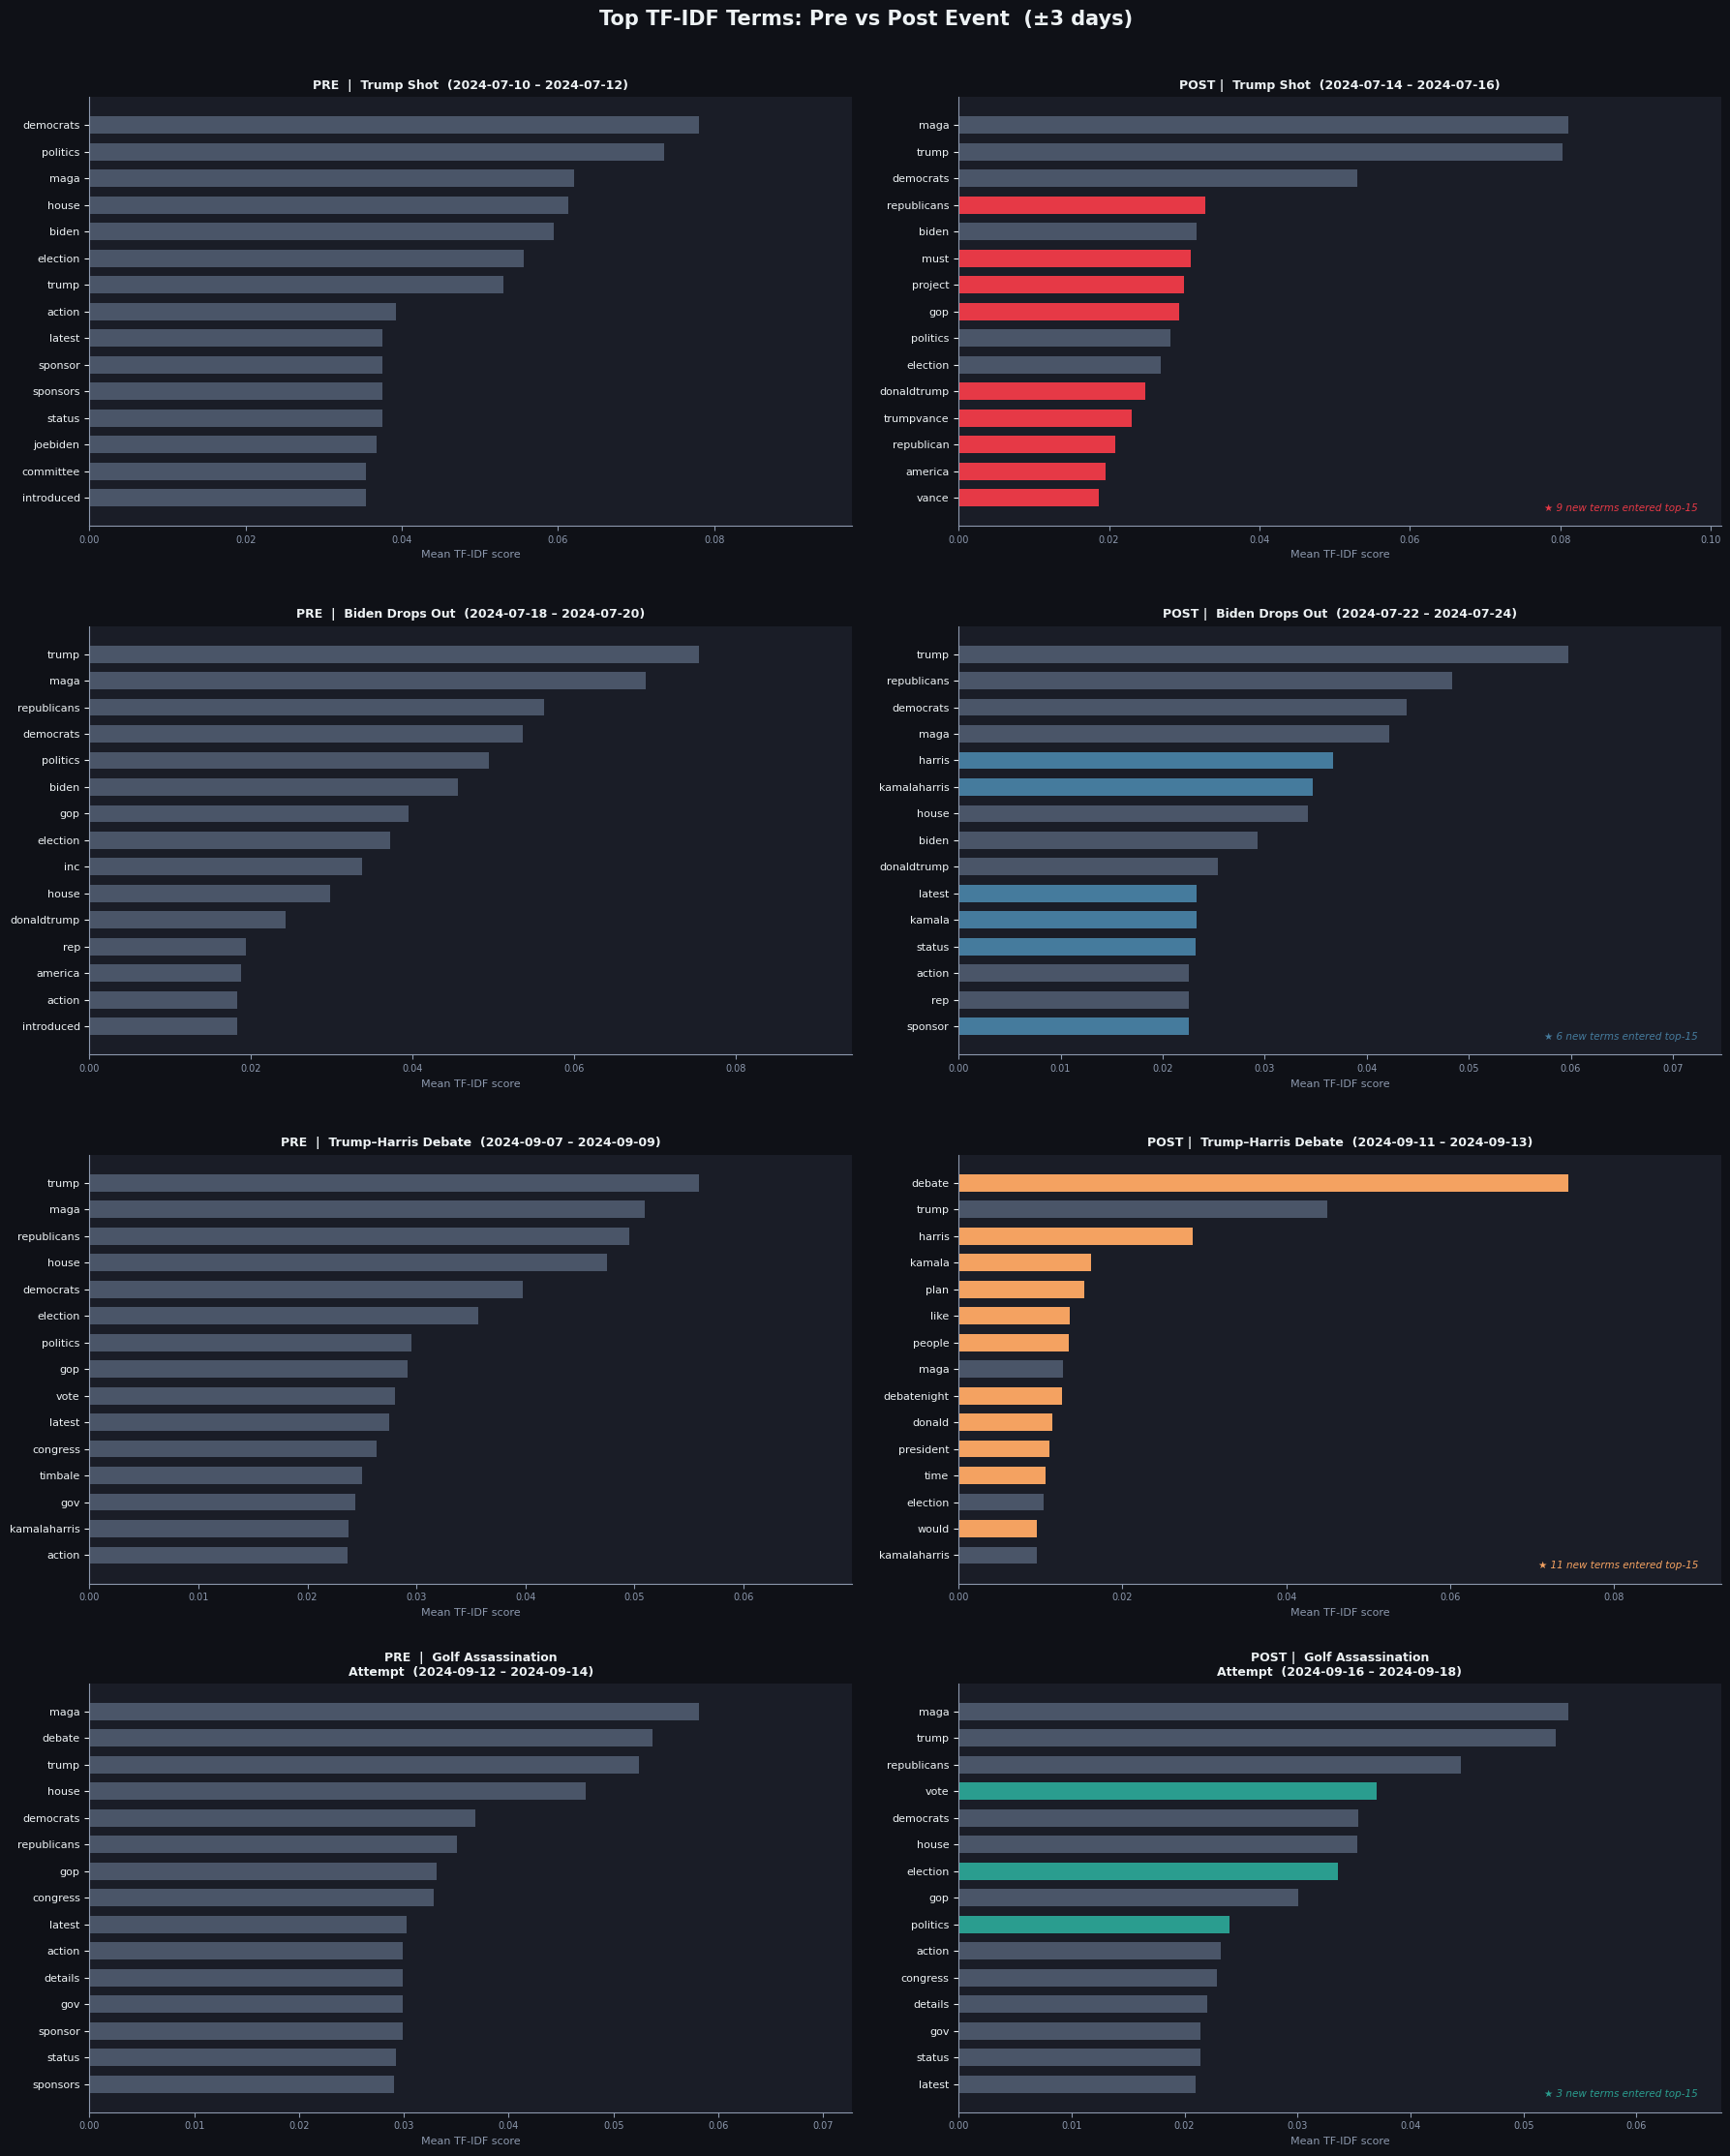

In [5]:
def top_tfidf(texts, n=15):
    """Return top-n terms by mean TF-IDF score."""
    if len(texts) < 3:
        return pd.Series(dtype=float)
    vec = TfidfVectorizer(token_pattern=r'\b\w{3,}\b', min_df=2, max_features=5000)
    mat = vec.fit_transform(texts)
    means = pd.Series(mat.mean(axis=0).A1, index=vec.get_feature_names_out())
    return means.nlargest(n)


fig, axes = plt.subplots(4, 2, figsize=(18, 22))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Top TF-IDF Terms: Pre vs Post Event  (±3 days)',
             color=TEXT_PRIMARY, fontsize=15, fontweight='bold', y=1.01)

for row, ev in enumerate(EVENTS):
    pre, post = get_window(df_clean, ev['date'])
    pre_top  = top_tfidf(pre['text_norm'].tolist())
    post_top = top_tfidf(post['text_norm'].tolist())

    pre_terms  = set(pre_top.index)
    post_terms = set(post_top.index)
    new_terms  = post_terms - pre_terms   # entered top-15 only after event

    for col, (top, title, window_label) in enumerate([
        (pre_top,  f'PRE  |  {ev["label"]}  ({(ev["date"] - pd.Timedelta(days=WINDOW)).date()} – {(ev["date"] - pd.Timedelta(days=1)).date()})', 'pre'),
        (post_top, f'POST |  {ev["label"]}  ({(ev["date"] + pd.Timedelta(days=1)).date()} – {(ev["date"] + pd.Timedelta(days=WINDOW)).date()})', 'post'),
    ]):
        ax = axes[row][col]
        ax.set_facecolor(BG_PANEL)

        terms  = top.index[::-1]
        values = top.values[::-1]

        bar_colors = []
        for t in terms:
            if window_label == 'post' and t in new_terms:
                bar_colors.append(ev['color'])   # highlight new terms
            else:
                bar_colors.append('#4a5568')

        bars = ax.barh(terms, values, color=bar_colors, edgecolor='none', height=0.65)

        ax.set_title(title, color=TEXT_PRIMARY, fontsize=9, fontweight='bold', pad=6)
        ax.set_xlabel('Mean TF-IDF score', color=TEXT_MUTED, fontsize=8)
        ax.tick_params(axis='y', labelsize=8, colors=TEXT_PRIMARY)
        ax.tick_params(axis='x', labelsize=7, colors=TEXT_MUTED)
        ax.set_xlim(0, max(values) * 1.25)

        if window_label == 'post':
            ax.annotate(f'★ {len(new_terms)} new terms entered top-15',
                        xy=(0.97, 0.03), xycoords='axes fraction',
                        ha='right', va='bottom', fontsize=7.5,
                        color=ev['color'], fontstyle='italic')

plt.tight_layout(h_pad=2.5, w_pad=2)
plt.show()


## 2 · Buzz-Group Composition Shift

How the TrumpBuzz / HarrisBuzz / ElectionBuzz split changes before vs after each event.

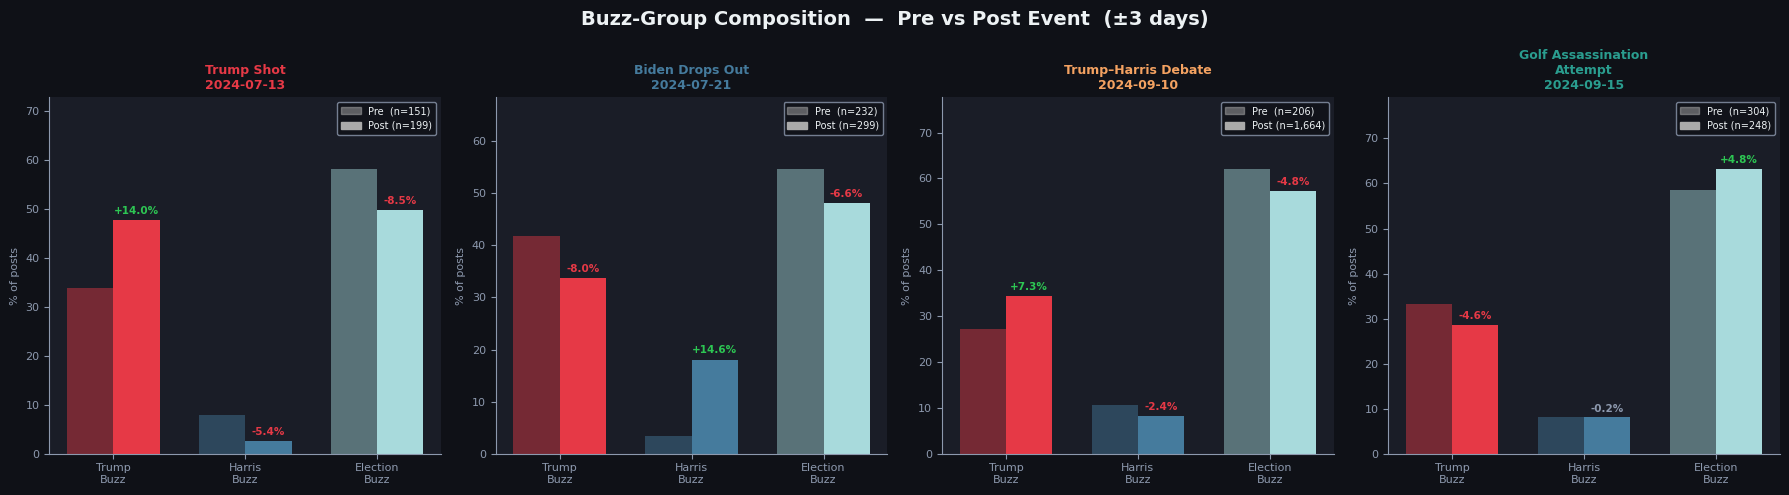

In [6]:
BUZZ_COLORS = {'TrumpBuzz': REPUBLICAN, 'HarrisBuzz': DEMOCRAT, 'ElectionBuzz': NEUTRAL}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Buzz-Group Composition  —  Pre vs Post Event  (±3 days)',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold')

for ax, ev in zip(axes, EVENTS):
    ax.set_facecolor(BG_PANEL)
    pre, post = get_window(df_clean, ev['date'])

    def buzz_pct(df):
        vc = df['buzz_group'].value_counts(normalize=True) * 100
        return {k: vc.get(k, 0) for k in ['TrumpBuzz', 'HarrisBuzz', 'ElectionBuzz']}

    pre_pct  = buzz_pct(pre)
    post_pct = buzz_pct(post)

    categories = list(BUZZ_COLORS.keys())
    x = np.arange(len(categories))
    w = 0.35

    pre_vals  = [pre_pct[c]  for c in categories]
    post_vals = [post_pct[c] for c in categories]

    bars_pre  = ax.bar(x - w/2, pre_vals,  w, color=[BUZZ_COLORS[c] for c in categories],
                       alpha=0.45, edgecolor='none', label='Pre')
    bars_post = ax.bar(x + w/2, post_vals, w, color=[BUZZ_COLORS[c] for c in categories],
                       alpha=1.0,  edgecolor='none', label='Post')

    # Annotate delta
    for i, (cat, pv, pov) in enumerate(zip(categories, pre_vals, post_vals)):
        delta = pov - pv
        sign  = '+' if delta >= 0 else ''
        color = '#2dc653' if delta > 0.5 else ('#e63946' if delta < -0.5 else TEXT_MUTED)
        ax.text(i + w/2, pov + 0.8, f'{sign}{delta:.1f}%',
                ha='center', va='bottom', fontsize=7.5, color=color, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(['Trump\nBuzz', 'Harris\nBuzz', 'Election\nBuzz'], fontsize=8)
    ax.set_ylabel('% of posts', color=TEXT_MUTED, fontsize=8)
    ax.set_title(f'{ev["label"]}\n{ev["date"].date()}',
                 color=ev['color'], fontsize=9, fontweight='bold')
    ax.tick_params(colors=TEXT_MUTED, labelsize=8)
    ax.set_ylim(0, max(max(pre_vals), max(post_vals)) * 1.25)

    pre_patch  = mpatches.Patch(color='#aaaaaa', alpha=0.5, label=f'Pre  (n={len(pre):,})')
    post_patch = mpatches.Patch(color='#aaaaaa', alpha=1.0, label=f'Post (n={len(post):,})')
    ax.legend(handles=[pre_patch, post_patch], fontsize=7, loc='upper right',
              facecolor=BG_DARK, edgecolor=TEXT_MUTED, labelcolor=TEXT_PRIMARY)

plt.tight_layout()
plt.show()


## 3 · Daily Post Volume & Buzz-Group Stacked Area

7-day window centred on each event. Event day marked with a vertical line.

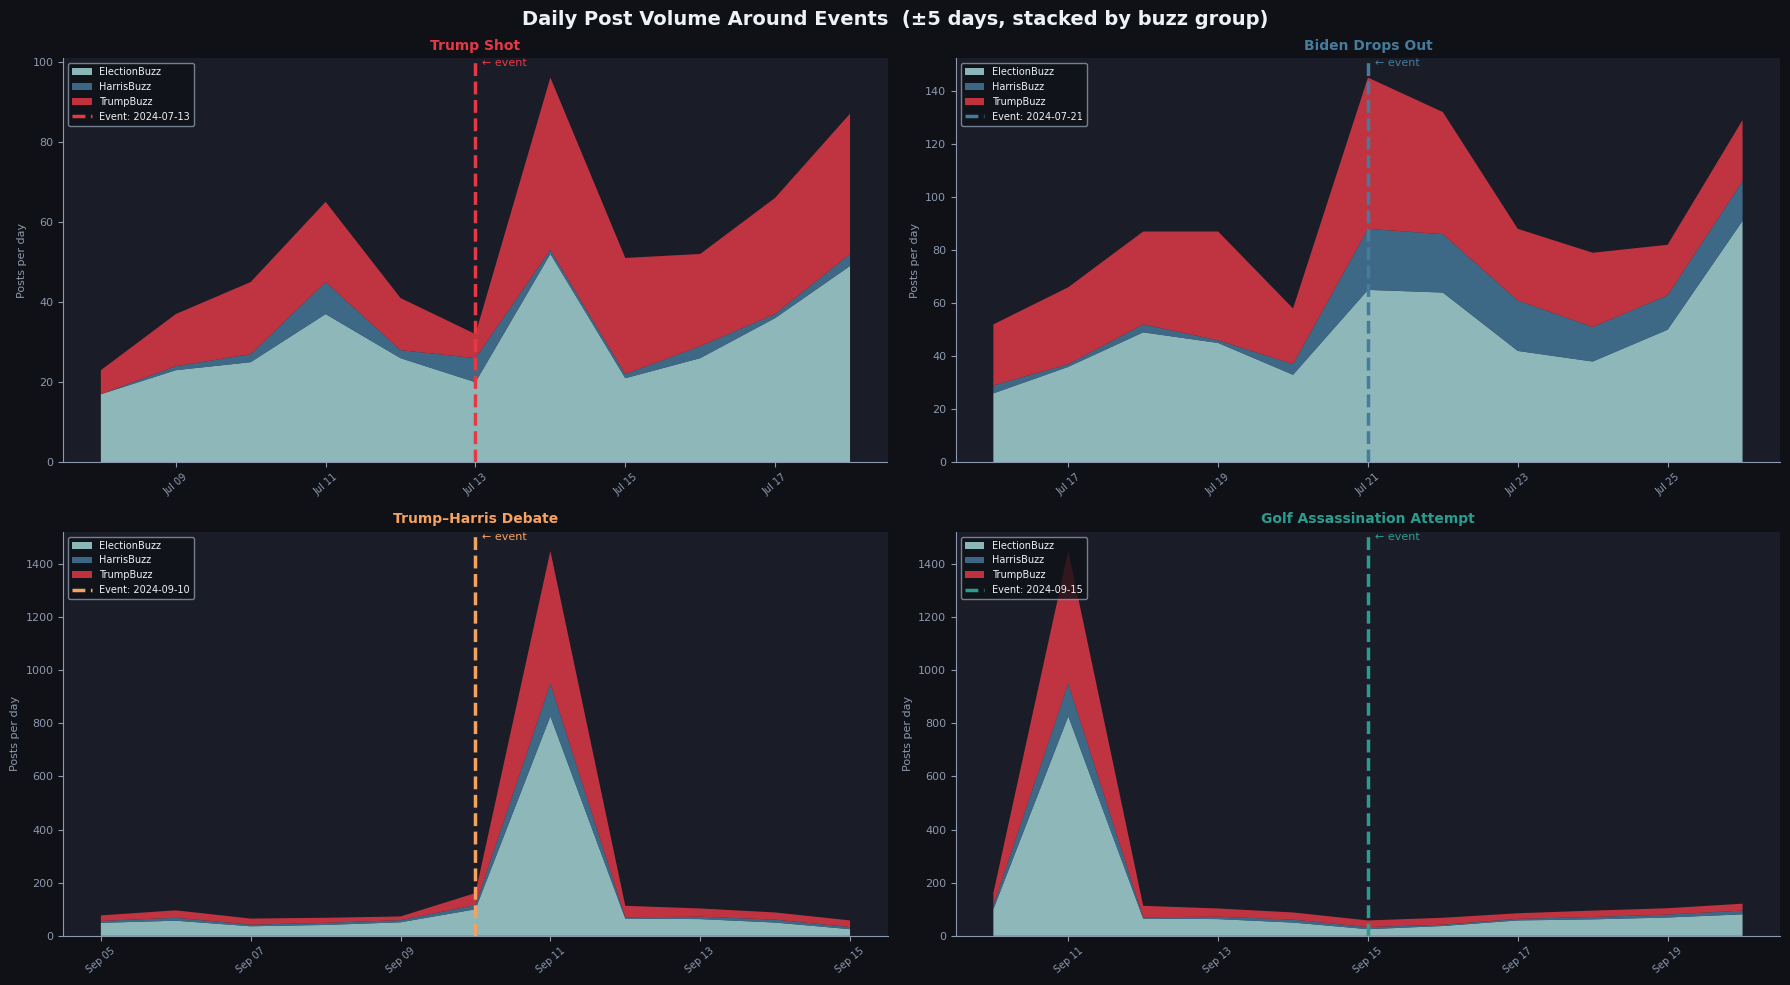

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Daily Post Volume Around Events  (±5 days, stacked by buzz group)',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold')

WINDOW_VOL = 5

for ax, ev in zip(axes.flat, EVENTS):
    ax.set_facecolor(BG_PANEL)
    start = ev['date'] - pd.Timedelta(days=WINDOW_VOL)
    end   = ev['date'] + pd.Timedelta(days=WINDOW_VOL)
    mask  = (df_clean['date'] >= start) & (df_clean['date'] <= end)
    sub   = df_clean[mask]

    daily = (
        sub.groupby(['date', 'buzz_group'])
        .size()
        .unstack(fill_value=0)
        .reindex(pd.date_range(start, end), fill_value=0)
    )
    for col in ['TrumpBuzz', 'HarrisBuzz', 'ElectionBuzz']:
        if col not in daily.columns:
            daily[col] = 0

    ax.stackplot(
        daily.index,
        daily['ElectionBuzz'], daily['HarrisBuzz'], daily['TrumpBuzz'],
        labels=['ElectionBuzz', 'HarrisBuzz', 'TrumpBuzz'],
        colors=[NEUTRAL, DEMOCRAT, REPUBLICAN],
        alpha=0.82
    )

    # Event line
    ax.axvline(ev['date'], color=ev['color'], lw=2.5, ls='--', zorder=5,
               label=f'Event: {ev["date"].date()}')
    ax.text(ev['date'], ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 10,
            '  ← event', color=ev['color'], fontsize=8, va='top', zorder=6)

    ax.set_title(ev['label'].replace('\n', ' '), color=ev['color'],
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Posts per day', color=TEXT_MUTED, fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=40, colors=TEXT_MUTED, labelsize=7)
    ax.tick_params(axis='y', colors=TEXT_MUTED, labelsize=8)
    ax.legend(fontsize=7, loc='upper left',
              facecolor=BG_DARK, edgecolor=TEXT_MUTED, labelcolor=TEXT_PRIMARY)

plt.tight_layout()
plt.show()

# 2) Event-Based  NLP

zie notebook: **2.3_NLP.ipynb**

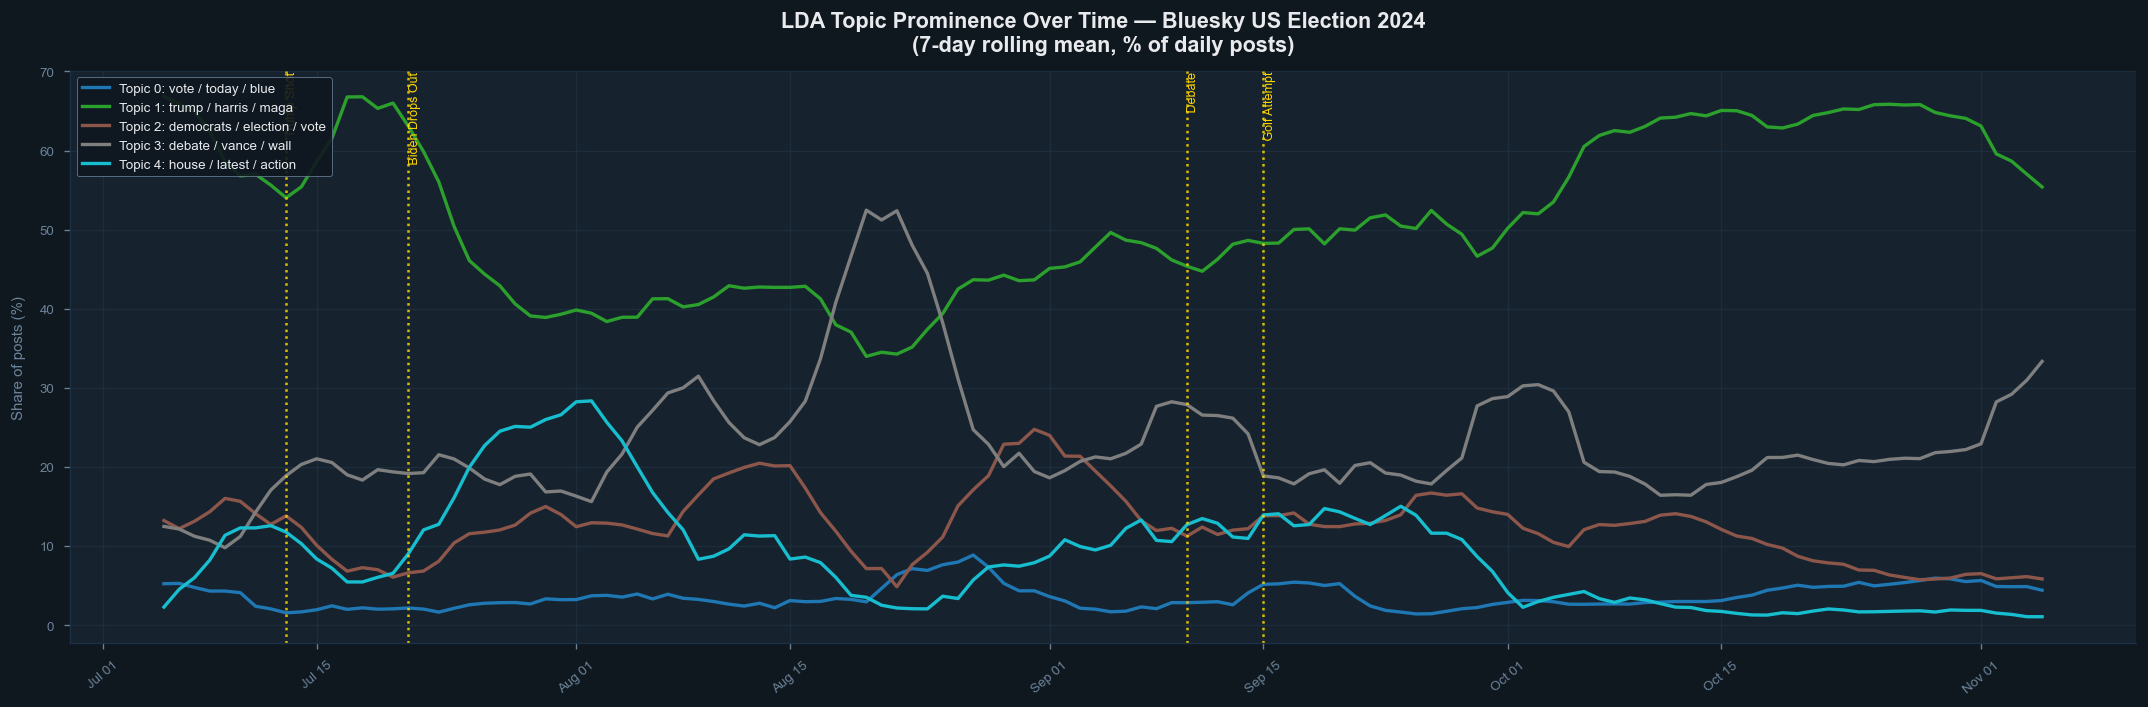

# 3) Event-Based Sentiment Analysis

zie notebook: **2.4_sentiment_analysis.ipynb**

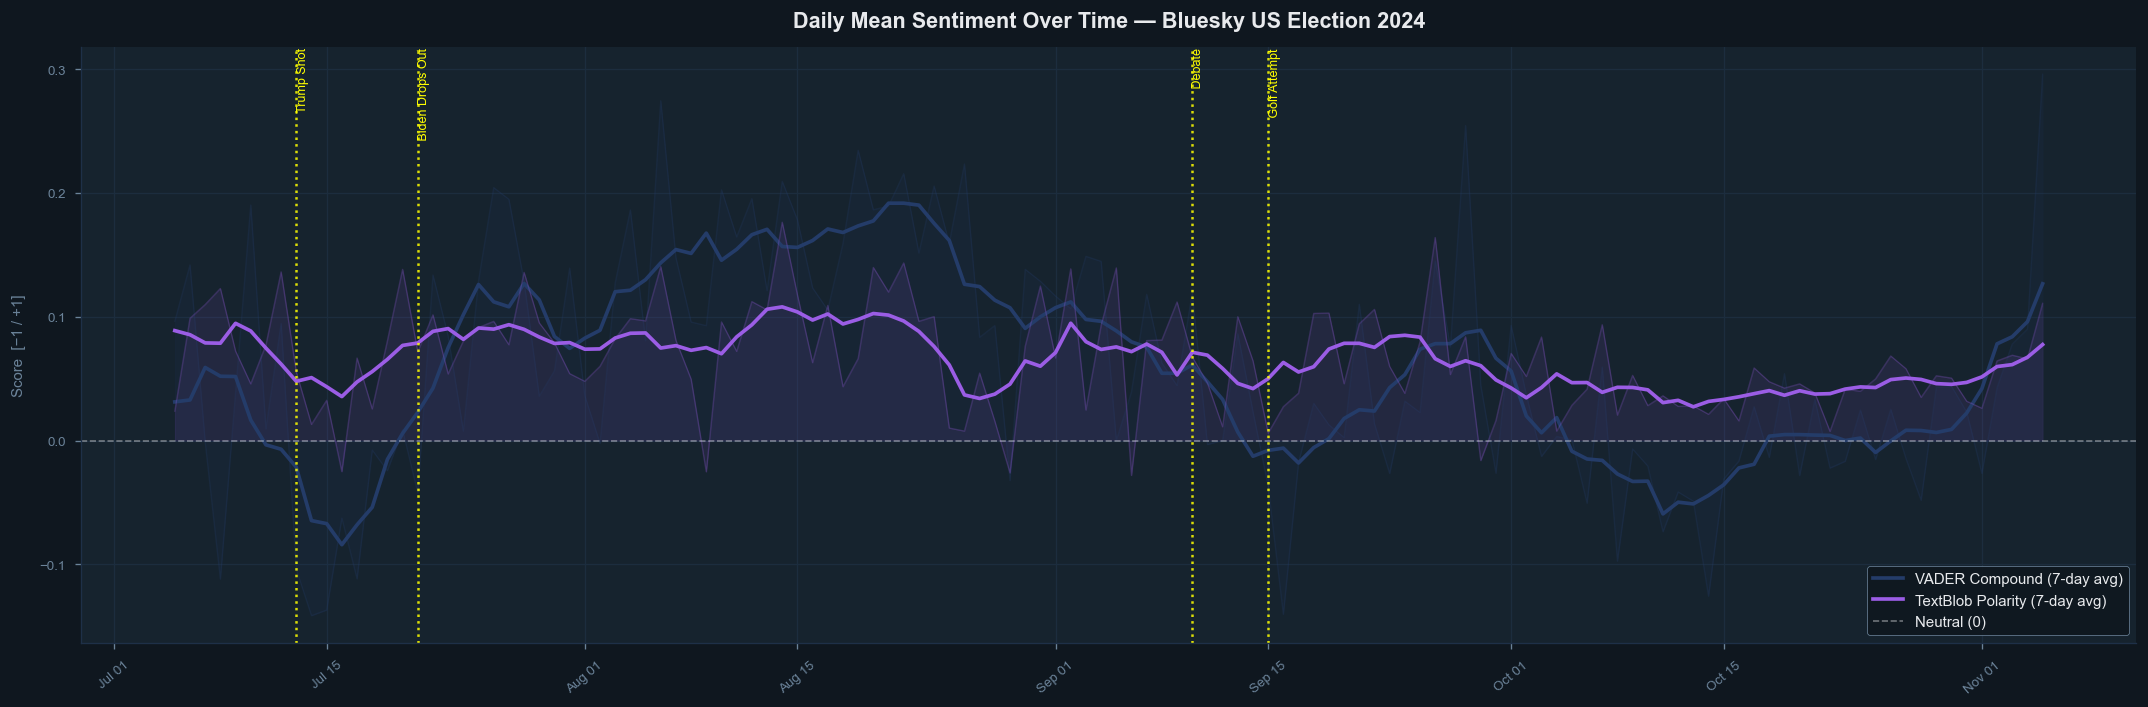

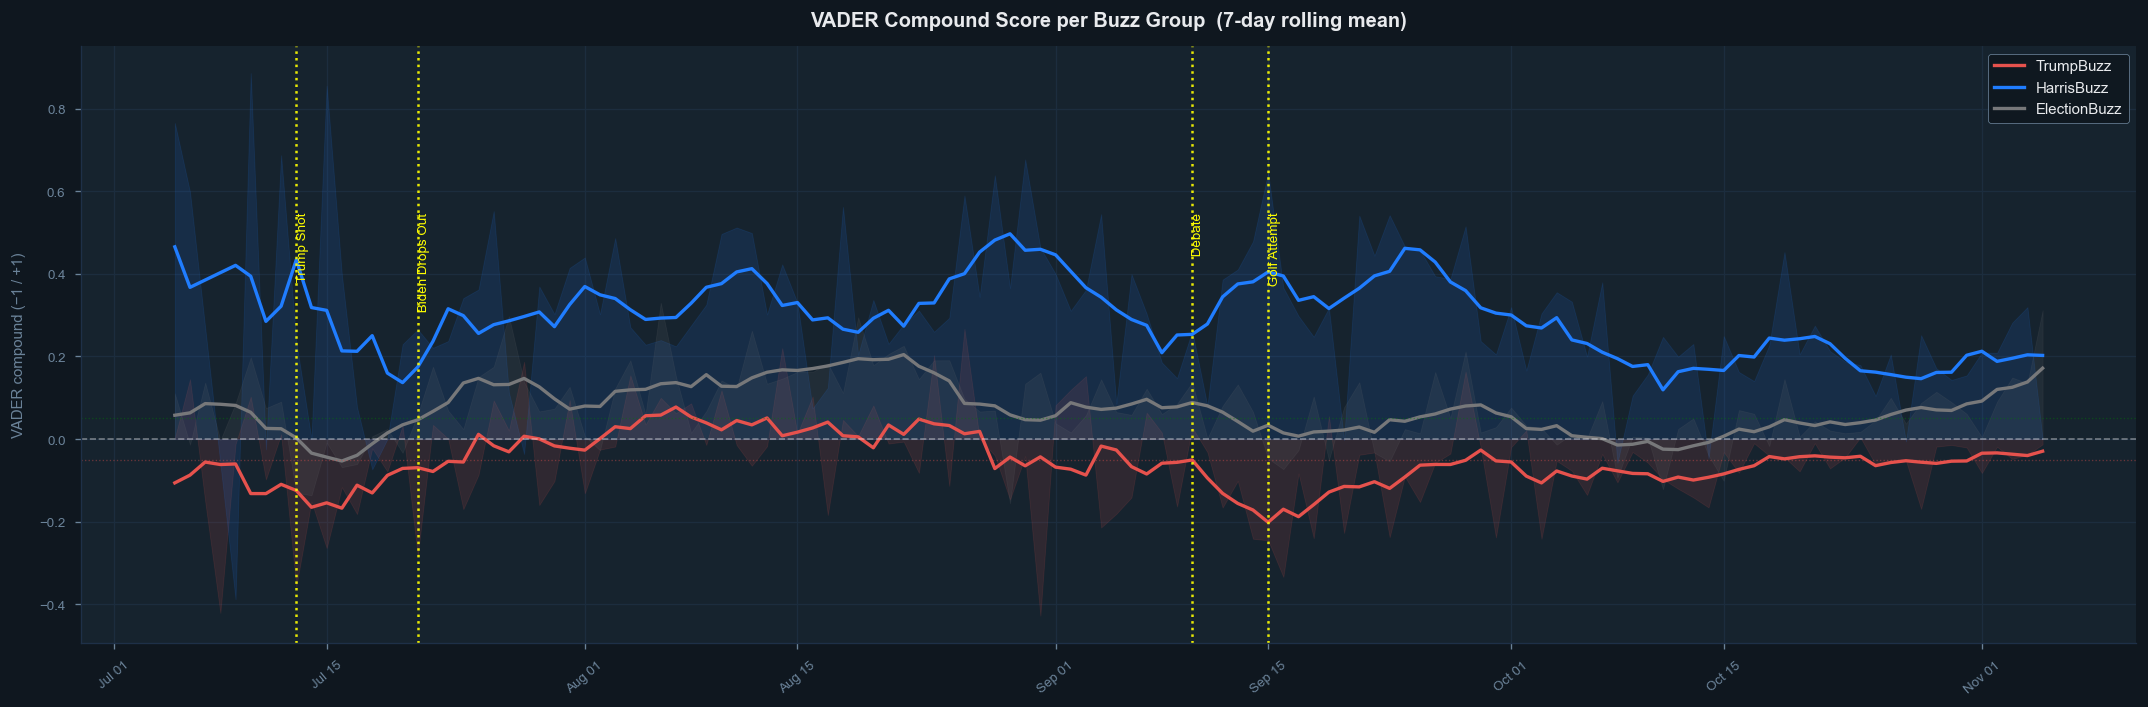

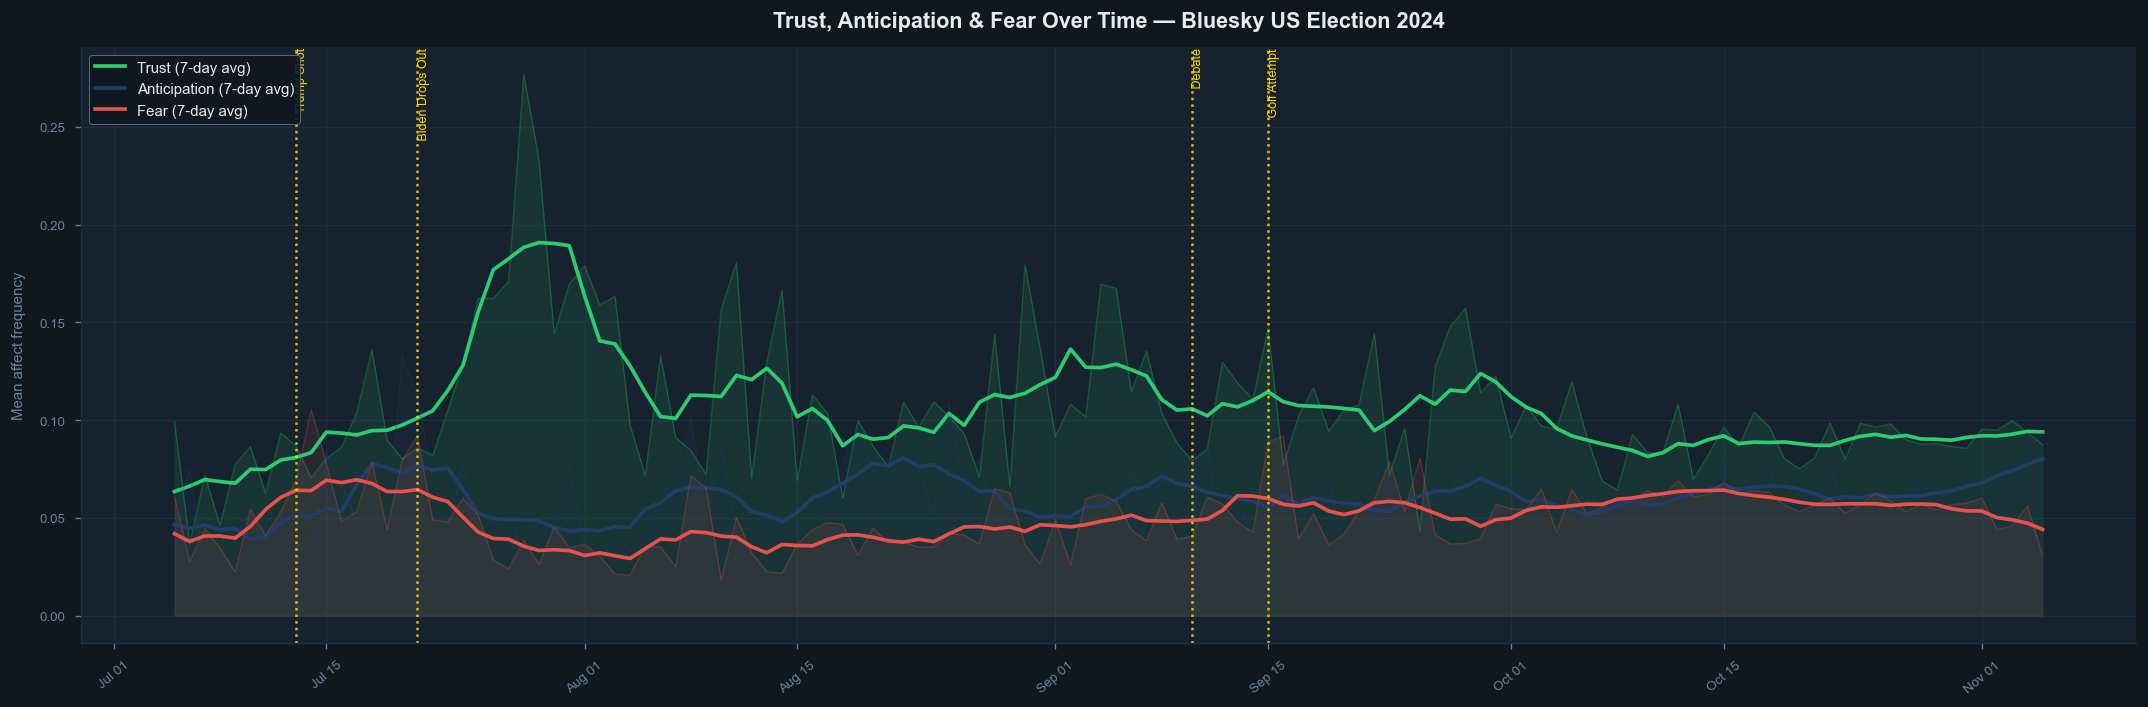